# Análisis Exploratorio de Datos (EDA) dirigido
### Campaña de marketing bancario — predicción de suscripción a depósito a plazo

**Componente:** análisis exploratorio orientado al modelado · Persona A · rama `feature/eda`
**Conjunto de datos:** Bank Marketing (UCI Machine Learning Repository)

---

## 0. Requisitos del entorno

Librerías necesarias para ejecutar este notebook. Descomenta la línea de instalación si trabajas en un entorno nuevo.

In [1]:
# Instalación de dependencias (descomentar si es necesario):
# !pip install pandas numpy matplotlib seaborn

import sys, pandas, numpy, matplotlib, seaborn
for nombre, modulo in [("Python", sys), ("pandas", pandas), ("numpy", numpy),
                       ("matplotlib", matplotlib), ("seaborn", seaborn)]:
    version = sys.version.split()[0] if nombre == "Python" else modulo.__version__
    print(f"{nombre:12}: {version}")

Python      : 3.14.3
pandas      : 3.0.1
numpy       : 2.4.3
matplotlib  : 3.10.8
seaborn     : 0.13.2


## 1. Contexto de negocio y objetivo analítico

La entidad ejecuta campañas de telemarketing para la contratación de un **depósito a plazo**. Dado que cada contacto tiene un coste operativo y la tasa de conversión histórica es baja, el objetivo es desarrollar un modelo que **estime la probabilidad de suscripción de cada cliente**, de modo que la campaña priorice a los clientes con mayor propensión y se optimice el retorno del esfuerzo comercial.

**Naturaleza del problema.** Clasificación binaria supervisada (variable objetivo `y` ∈ {no, yes}), con **clases desbalanceadas**.

**Restricción operativa.** El modelo debe priorizar clientes **antes** de realizar la llamada; toda variable cuyo valor solo se conozca durante o después del contacto queda excluida como predictor (véase sección 5).

> **Nota metodológica.** El análisis exploratorio se desarrolla sobre el **conjunto de datos completo** para comprender su estructura. La prevención de la fuga de datos (*data leakage*) se aplica en la fase de preprocesado: las transformaciones que **ajustan parámetros a partir de los datos** (imputación, escalado, codificación) se ajustan **exclusivamente sobre el conjunto de entrenamiento** mediante la partición `train/test`. Es en ese punto —y no en el EDA descriptivo— donde reside la protección frente al *leakage*.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

# Paleta corporativa para las visualizaciones
NAVY, STEEL, BRICK, GOLD, GREY = "#2A4B7C", "#3C8DAD", "#C1442E", "#B58A2E", "#B8BDC4"
INK = "#1F2733"
plt.rcParams.update({"axes.titleweight": "bold", "axes.titlecolor": INK, "figure.dpi": 110})

In [3]:
# El separador de este dataset es ';' (no la coma por defecto)
DATA_PATH = "src/data_sample/bank-full.csv"
df = pd.read_csv(DATA_PATH, sep=";")

# Variable objetivo numérica auxiliar para agregaciones (1 = contrata, 0 = no)
df["yb"] = (df["y"] == "yes").astype(int)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,yb
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


## 2. Estructura general del conjunto de datos

Revisión inicial de tamaño, tipos de dato, valores nulos y duplicados: es el diagnóstico previo a cualquier análisis en profundidad.

In [4]:
print(f"Dimensiones: {df.shape[0]:,} registros × {df.shape[1]} columnas")
df.info()

Dimensiones: 45,211 registros × 18 columnas
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
 17  yb         45211 non-null  int64
dtypes: int64(8), str(10)
memory usage: 8.4 MB


In [5]:
import sys
sys.path.append('./')
sys.path.append('./src')

In [6]:
from utils.definiciones import describe_df, tipifica_variables

In [7]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
age,int64,0.0,77,0.17
job,str,0.0,12,0.03
marital,str,0.0,3,0.01
education,str,0.0,4,0.01
default,str,0.0,2,0.00
balance,int64,0.0,7168,15.85
housing,str,0.0,2,0.00
loan,str,0.0,2,0.00
contact,str,0.0,3,0.01
day,int64,0.0,31,0.07


In [8]:
tipifica_variables(df, 10, 0.3)

,nombre_variable,tipo_sugerido
0,age,Numérica Discreta
1,job,Numérica Discreta
2,marital,Categórica
3,education,Categórica
4,default,Binaria
5,balance,Numérica Continua
6,housing,Binaria
7,loan,Binaria
8,contact,Categórica
9,day,Numérica Discreta


In [9]:
# Nulos explícitos y registros duplicados
print("Valores nulos explícitos:", df.isna().sum().sum())
print("Registros duplicados     :", df.duplicated().sum())

Valores nulos explícitos: 0
Registros duplicados     : 0


In [10]:
# Estadísticos descriptivos (numéricas y categóricas)
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


**Observación.** No se detectan valores nulos explícitos ni registros duplicados. No obstante, el conjunto **codifica la ausencia de información mediante la categoría `"unknown"`** (se analiza en la sección 6). La cardinalidad de las variables categóricas es baja.

## 3. Análisis de la variable objetivo

Es el bloque determinante del EDA: la distribución del objetivo condiciona la métrica de evaluación y las técnicas de modelado.

In [11]:
df["y"].value_counts(normalize=True).round(4)

y
no     0.883
yes    0.117
Name: proportion, dtype: float64

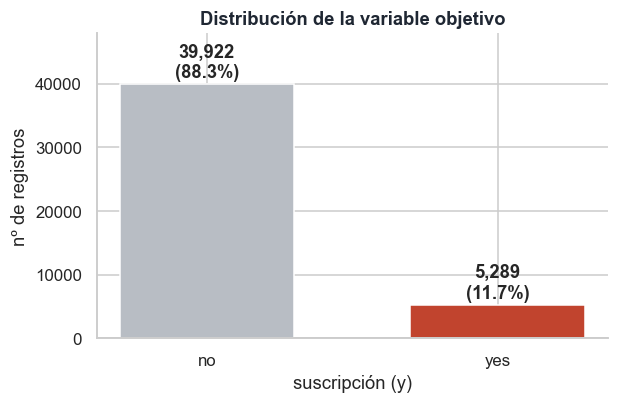

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.6))
vc = df["y"].value_counts()[["no", "yes"]]
bars = ax.bar(["no", "yes"], vc.values, color=[GREY, BRICK], width=0.6)
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 400,
            f"{v:,}\n({v/vc.sum()*100:.1f}%)", ha="center", va="bottom", fontweight="bold")
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("nº de registros"); ax.set_xlabel("suscripción (y)")
ax.set_ylim(0, vc.max()*1.2)
sns.despine(); plt.show()

**Hallazgo → acción.** La variable objetivo presenta un **desbalance acusado (≈ 88 / 12)**: solo el ~12 % contrata. En consecuencia:

- La *accuracy* no es una métrica adecuada (un clasificador trivial que prediga siempre "no" alcanzaría ~88 % sin valor de negocio).
- **Recomendación (modelado):** emplear **F1-score, recall y ROC-AUC**; aplicar `stratify` en la partición; evaluar `class_weight` o remuestreo.

## 4. Consideración crítica: fuga de datos en la variable `duration`

Este es el hallazgo más relevante para el diseño del modelo.

In [13]:
# duration presenta la mayor correlación con el objetivo...
num = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
df[num + ["yb"]].corr()["yb"].sort_values(ascending=False).round(3)

yb          1.000
duration    0.395
pdays       0.104
previous    0.093
balance     0.053
age         0.025
day        -0.028
campaign   -0.073
Name: yb, dtype: float64

In [14]:
# ...pero su magnitud solo se conoce una vez finalizada la llamada
df.groupby("y")["duration"].mean().round(0)

y
no     221.0
yes    537.0
Name: duration, dtype: float64

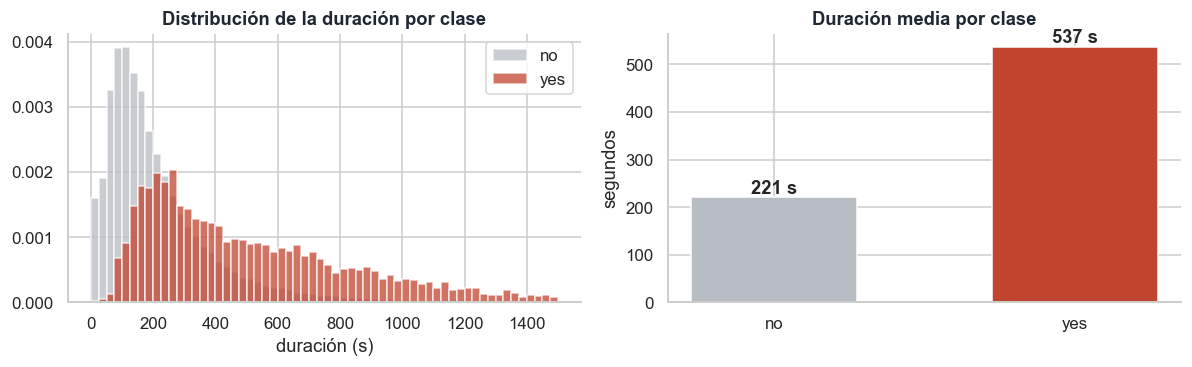

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for lab, c in [("no", GREY), ("yes", BRICK)]:
    axes[0].hist(df.loc[df["y"] == lab, "duration"], bins=60, range=(0, 1500),
                 alpha=0.75, color=c, label=lab, density=True)
axes[0].set_title("Distribución de la duración por clase")
axes[0].set_xlabel("duración (s)"); axes[0].legend()

m = df.groupby("y")["duration"].mean()[["no", "yes"]]
bars = axes[1].bar(["no", "yes"], m.values, color=[GREY, BRICK], width=0.55)
for b, v in zip(bars, m.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 8, f"{v:.0f} s", ha="center", fontweight="bold")
axes[1].set_title("Duración media por clase"); axes[1].set_ylabel("segundos")
sns.despine(); plt.tight_layout(); plt.show()

**Razonamiento y decisión.** `duration` es la variable más correlacionada con el objetivo (r ≈ 0.39; media de ~537 s en suscripciones frente a ~221 s en no suscripciones). Sin embargo, **su valor solo se conoce una vez finalizada la llamada** y no está disponible en el momento de decidir el contacto.

Incluirla constituiría una **fuga de datos temporal**: produciría métricas artificialmente altas y no representativas del escenario real, además de invalidar el objetivo de negocio.

**Decisión recomendada:** **excluir `duration`** del conjunto de variables predictoras (su uso se limita al EDA). *Coherente con la advertencia del repositorio UCI.*

## 5. Variables numéricas: distribución, escala y valores atípicos

In [16]:
df[num].skew().sort_values(ascending=False).round(2)

previous    41.85
balance      8.36
campaign     4.90
duration     3.14
pdays        2.62
age          0.68
day          0.09
dtype: float64

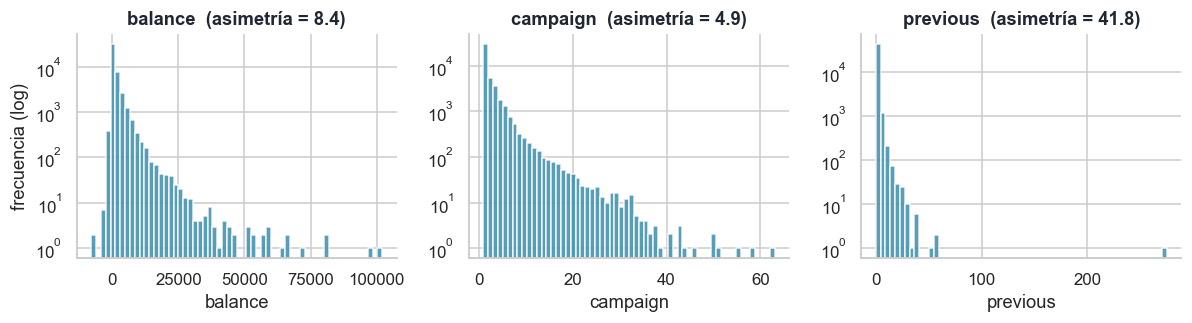

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))
for ax, c in zip(axes, ["balance", "campaign", "previous"]):
    ax.hist(df[c], bins=60, color=STEEL, alpha=0.85)
    ax.set_yscale("log")   # escala log: colas muy largas
    ax.set_title(f"{c}  (asimetría = {df[c].skew():.1f})"); ax.set_xlabel(c)
axes[0].set_ylabel("frecuencia (log)")
sns.despine(); plt.tight_layout(); plt.show()

In [18]:
# Casos particulares a documentar
print(f"balance negativo : {(df['balance'] < 0).mean()*100:.1f}% de los registros (saldos deudores legítimos)")
print(f"pdays == -1      : {(df['pdays'] == -1).mean()*100:.1f}% (valor centinela: sin contacto previo)")

balance negativo : 8.3% de los registros (saldos deudores legítimos)
pdays == -1      : 81.7% (valor centinela: sin contacto previo)


**Hallazgos → acciones:**

- **Asimetría positiva pronunciada** en `previous`, `balance`, `campaign` y `duration` → **transformación logarítmica/robusta** para las variables retenidas.
- `balance` **negativo** (~8 %): saldos deudores legítimos (descubiertos), **no errores** → conservar, no tratar como atípico.
- **Escalas heterogéneas** → **estandarización/normalización** para modelos sensibles a la magnitud (KNN, SVM, lineales).
- `pdays = -1` es un **valor centinela** ("sin contacto previo") → recodificar como **indicador binario**, no como número.

## 6. Variables categóricas y calidad del dato

La ausencia de información se codifica como la categoría `"unknown"`. Su identificación es esencial para un tratamiento correcto.

In [19]:
for c in df.select_dtypes("object").columns:
    pct = (df[c] == "unknown").mean() * 100
    print(f"{c:11} | {df[c].nunique():2} categorías | unknown: {pct:5.1f}%")

job         | 12 categorías | unknown:   0.6%
marital     |  3 categorías | unknown:   0.0%
education   |  4 categorías | unknown:   4.1%
default     |  2 categorías | unknown:   0.0%
housing     |  2 categorías | unknown:   0.0%
loan        |  2 categorías | unknown:   0.0%
contact     |  3 categorías | unknown:  28.8%
month       | 12 categorías | unknown:   0.0%
poutcome    |  4 categorías | unknown:  81.7%
y           |  2 categorías | unknown:   0.0%


C:\Users\Usuario\AppData\Local\Temp\ipykernel_23492\2713280694.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes("object").columns:


| Variable | % `"unknown"` | Interpretación y tratamiento |
|---|---|---|
| `poutcome` | ~81.7 % | Coincide con `pdays = -1`: clientes **sin campaña previa**. Recodificar como categoría específica. |
| `contact`  | ~28.8 % | Canal no registrado; asociado a menor conversión. Mantener como categoría. |
| `education`| ~4.1 %  | Ausencia real de bajo volumen; imputar (moda) o mantener. |
| `job`      | ~0.6 %  | Ausencia residual; imputar o mantener. |

- **Cardinalidad baja** (máx. 12 categorías) → **One-Hot Encoding** viable sin expansión excesiva.
- **Redundancia:** `pdays = -1`, `previous = 0` y `poutcome = "unknown"` describen el mismo estado ("sin contacto previo") → evaluar **multicolinealidad**.

## 7. Relación entre variables predictoras y la variable objetivo

Identificación de las variables con mayor poder discriminante y de mayor valor accionable para el negocio.

In [20]:
base = df["yb"].mean() * 100   # tasa media global de suscripción

def tasa_por(col, orden=None):
    t = df.groupby(col, observed=True)["yb"].mean().mul(100)
    return t.reindex(orden) if orden else t.sort_values(ascending=False)

tasa_por("poutcome").round(1)

poutcome
success    64.7
other      16.7
failure    12.6
unknown     9.2
Name: yb, dtype: float64

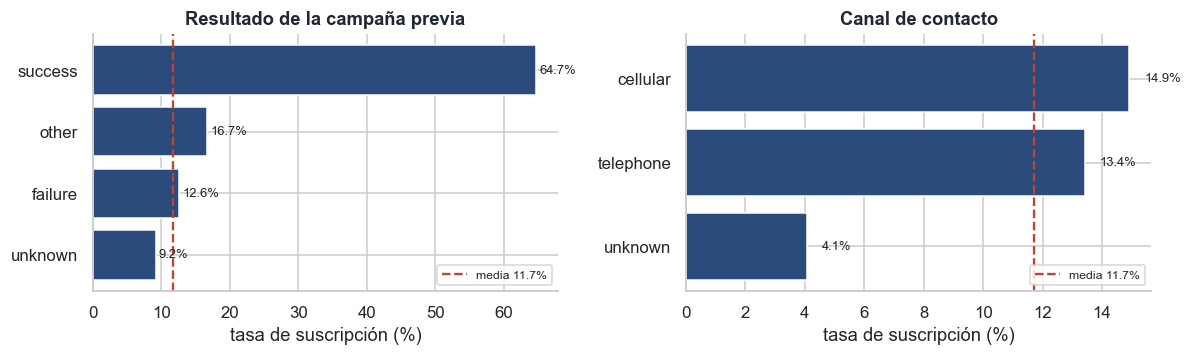

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, ttl in [(axes[0], "poutcome", "Resultado de la campaña previa"),
                     (axes[1], "contact", "Canal de contacto")]:
    t = tasa_por(col)
    ax.barh(t.index, t.values, color=NAVY)
    ax.axvline(base, color=BRICK, ls="--", lw=1.5, label=f"media {base:.1f}%")
    for i, v in enumerate(t.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8.5)
    ax.set_title(ttl); ax.set_xlabel("tasa de suscripción (%)")
    ax.legend(loc="lower right", fontsize=8); ax.invert_yaxis()
sns.despine(); plt.tight_layout(); plt.show()

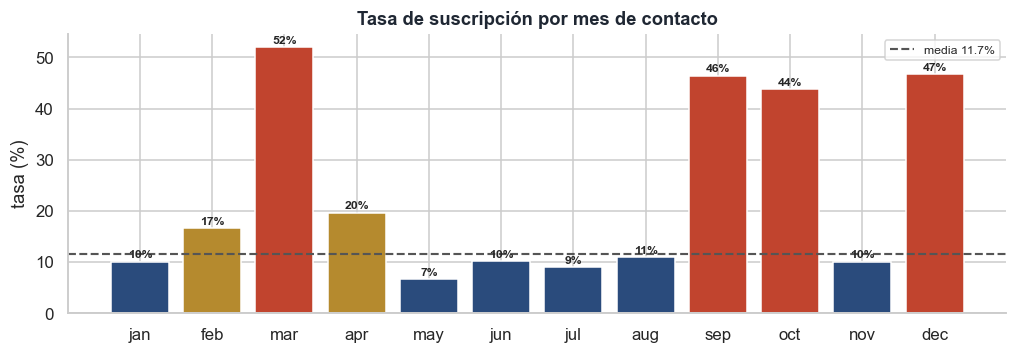

In [22]:
# Estacionalidad: tasa por mes de contacto
meses = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
t = tasa_por("month", meses)
fig, ax = plt.subplots(figsize=(11, 3.3))
colores = [BRICK if v >= 30 else (GOLD if v >= 15 else NAVY) for v in t.values]
ax.bar(t.index, t.values, color=colores)
ax.axhline(base, color="#555", ls="--", lw=1.4, label=f"media {base:.1f}%")
for i, v in enumerate(t.values):
    ax.text(i, v + 0.7, f"{v:.0f}%", ha="center", fontsize=8, fontweight="bold")
ax.set_title("Tasa de suscripción por mes de contacto"); ax.set_ylabel("tasa (%)")
ax.legend(fontsize=8); sns.despine(); plt.show()

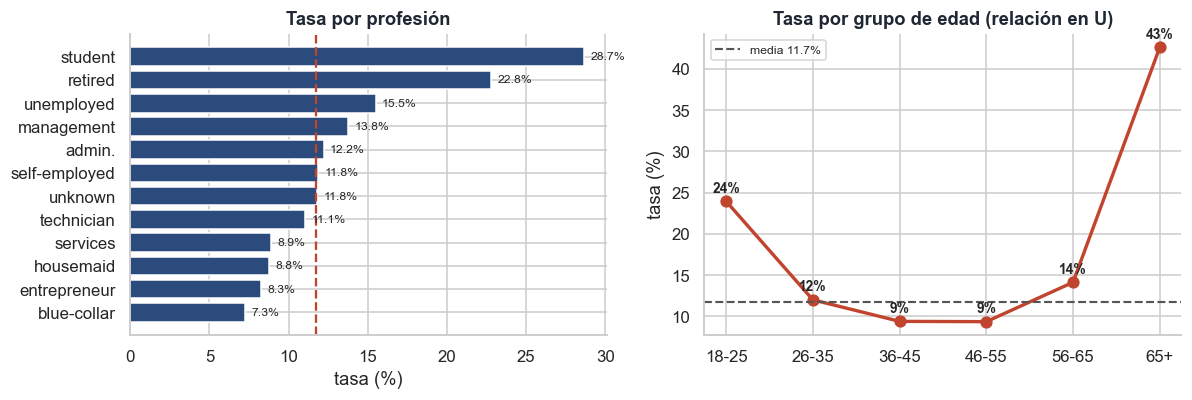

In [23]:
# Profesión y edad (grupos)
df["age_b"] = pd.cut(df["age"], [17,25,35,45,55,65,100],
                     labels=["18-25","26-35","36-45","46-55","56-65","65+"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

t = tasa_por("job")
axes[0].barh(t.index, t.values, color=NAVY); axes[0].axvline(base, color=BRICK, ls="--", lw=1.5)
for i, v in enumerate(t.values): axes[0].text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=8)
axes[0].set_title("Tasa por profesión"); axes[0].set_xlabel("tasa (%)"); axes[0].invert_yaxis()

ta = tasa_por("age_b", ["18-25","26-35","36-45","46-55","56-65","65+"])
axes[1].plot(ta.index, ta.values, "-o", color=BRICK, lw=2.2, ms=7)
axes[1].axhline(base, color="#555", ls="--", lw=1.4, label=f"media {base:.1f}%")
for x, v in zip(ta.index, ta.values): axes[1].text(x, v + 1.1, f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Tasa por grupo de edad (relación en U)"); axes[1].set_ylabel("tasa (%)"); axes[1].legend(fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

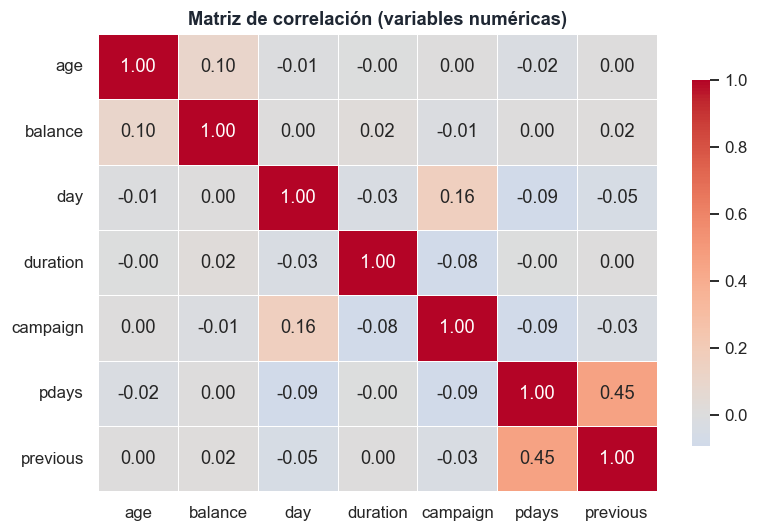

In [24]:
# Matriz de correlación de las variables numéricas
plt.figure(figsize=(7.5, 5))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación (variables numéricas)"); plt.tight_layout(); plt.show()

**Hallazgos con mayor relevancia para el negocio:**

- **Campaña previa (`poutcome`).** Un resultado `success` eleva la tasa al **~65 %** (frente al ~12 % medio): el histórico de conversión es el predictor de mayor poder discriminante.
- **Estacionalidad.** Conversión muy superior en **mar, sep, oct y dic**, y mínima en **mayo** —el mes de mayor volumen de contactos— → recomendación de **planificación temporal**.
- **Canal.** `contact = unknown` convierte mucho menos que `cellular`.
- **Edad.** Relación **no lineal (en U)**: **18-25** y **65+** superan a los tramos intermedios; explica la baja correlación lineal de `age`.
- **Situación crediticia.** Ausencia de hipoteca/préstamo se asocia a mayor conversión.
- **Saturación.** Con **> 3 contactos** la tasa cae; `campaign` correlaciona negativamente con el objetivo.

## 8. Síntesis de hallazgos y decisiones recomendadas

| Hallazgo | Implicación / acción recomendada | Responsable |
|---|---|---|
| Objetivo desbalanceado (88/12) | Métricas F1/recall/ROC-AUC; `stratify`; tratamiento de desbalance | Modelado |
| `duration` correlacionada pero posterior a la llamada | **Exclusión** del conjunto de predictores (fuga de datos) | Equipo |
| Asimetría en `previous`, `balance`, `campaign` | Transformación logarítmica/robusta | Preprocesado |
| `balance` negativo (saldos deudores) | Conservar; no tratar como atípico | Preprocesado |
| `pdays = -1` (valor centinela) | Recodificar como indicador binario | Preprocesado |
| `"unknown"` en `poutcome`/`contact`/`education` | Tratar como categoría, no como nulo | Preprocesado |
| Redundancia `pdays`/`previous`/`poutcome` | Evaluar multicolinealidad | Modelado |
| Cardinalidad baja (≤ 12) | One-Hot Encoding | Preprocesado |
| Escalas heterogéneas | Estandarización/normalización | Preprocesado |
| `poutcome`, estacionalidad, edad, crédito | Variables de alto valor predictivo; conservar | Modelado |

## 9. Conclusiones

1. El conjunto comprende ~45.000 clientes y 16 variables; la variable objetivo está **desbalanceada** (~12 % de suscripción), lo que condiciona la estrategia de evaluación.
2. **`duration`, pese a ser la más correlacionada con el objetivo, debe excluirse** por constituir una fuga de datos: solo se conoce tras la llamada. Su identificación es determinante para un modelo realista.
3. Los predictores de mayor valor de negocio son el **histórico de conversión** (`poutcome`), el **mes de contacto** y el **perfil del cliente** (edad, situación crediticia).
4. El análisis deja definidas las decisiones de preprocesado y selección de variables para las fases siguientes del pipeline.

---
*Análisis exploratorio realizado sobre el conjunto de datos completo. Las transformaciones que ajustan parámetros se aplican sobre el conjunto de entrenamiento en la fase de preprocesado.*

## Procesado

In [25]:
# Hacemos el split en Train y Test, stratify = Target

from sklearn.model_selection import train_test_split

X = df.drop(columns=['yb', 'y', 'duration', 'age_b']) # Excluimos la variable objetivo (yb), y las columnas que previamente hemos descartado
y = df['yb']                                          # Variable objetivo (target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y           # En clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 36168 filas  (80 %)
Test:  9043 filas  (20 %)


In [26]:
# Hacemos una visualización de las columnas que tenemos en train antes de cartar el modulo de segmentación de clientes
X_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
24001,36,technician,divorced,secondary,no,861,no,no,telephone,29,aug,2,-1,0,unknown
43409,24,student,single,secondary,no,4126,no,no,cellular,5,apr,4,185,7,failure
20669,44,technician,single,secondary,no,244,yes,no,cellular,12,aug,4,-1,0,unknown
18810,48,unemployed,married,secondary,no,0,no,no,telephone,31,jul,11,-1,0,unknown
23130,38,technician,married,secondary,no,257,no,no,cellular,26,aug,10,-1,0,unknown


In [27]:
X_train.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      6597
housing         2
loan            2
contact         3
day            31
month          12
campaign       47
pdays         533
previous       41
poutcome        4
dtype: int64

In [28]:
# Cargamos el modelo creado en el modulo de segmentación de clientes

import joblib

# Cargar el scaler y el modelo de clustering
scaler = joblib.load("src/models/scaler_segmentacion.pkl")
kmeans = joblib.load("src/models/kmeans_segmentacion.pkl")

print("Modelos cargados correctamente")

Modelos cargados correctamente


In [29]:
# Recuperar las columnas usadas en el scaler
feats = list(scaler.feature_names_in_)

In [30]:
def asignar_segmento(datos, scaler, kmeans):
    d = datos.copy()
    d["log_balance"] = np.sign(d["balance"]) * np.log1p(d["balance"].abs())
    d["housing_b"] = (d["housing"] == "yes").astype(int)
    d["loan_b"] = (d["loan"] == "yes").astype(int)
    d["contacted_before"] = (d["pdays"] != -1).astype(int)
    return kmeans.predict(scaler.transform(d[feats]))

In [31]:
# Aplicamos la función anterior para obtener los segmentos del train y test.
segmentos_train = asignar_segmento(X_train, scaler, kmeans)
segmentos_test = asignar_segmento(X_test, scaler, kmeans)


In [32]:
# Revisamos las columnas que el scaler tiene registradas como entrada.
scaler.feature_names_in_

array(['age', 'log_balance', 'campaign', 'previous', 'housing_b',
       'loan_b', 'contacted_before'], dtype=object)

In [33]:
# Incluimos la columna creada 'segment' en nuestros df (train y test)
X_train["segment"] = segmentos_train
X_test["segment"]  = segmentos_test

In [34]:
# Comprobamos que ambas se han incluido
print(X_test.columns)
print(X_train.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'segment'],
      dtype='str')
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'segment'],
      dtype='str')


In [35]:
# --- Feature engineering ---

# 1) Convertimos 'pdays' en binaria:
#    -1 significa que nunca fue contactado antes.
#    Cualquier otro valor indica contacto previo.
X_train['pdays'] = (X_train['pdays'] != -1).astype(int)
X_test['pdays']  = (X_test['pdays'] != -1).astype(int)

# 2) Recodeamos 'poutcome':
#    'unknown' se interpreta como "no hubo contacto previo".
X_train['poutcome'] = X_train['poutcome'].replace('unknown', 'no_previous_contact')
X_test['poutcome']  = X_test['poutcome'].replace('unknown', 'no_previous_contact')


# 3) Imputamos la moda de 'job' calculada en train:
#    Evita data leakage y mantiene consistencia entre train y test.
mode_job = X_train['job'].mode()[0]
X_train['job'] = X_train['job'].replace('unknown', mode_job)
X_test['job']  = X_test['job'].replace('unknown', mode_job)

# 4) Convertimos las columnas binarias a 0/1:
binarias = ["default", "housing", "loan"]

for col in binarias:
    X_train[col] = (X_train[col] == "yes").astype(int)
    X_test[col] = (X_test[col] == "yes").astype(int)


In [36]:
X_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,segment
24001,36,technician,divorced,secondary,0,861,0,0,telephone,29,aug,2,0,0,no_previous_contact,1
43409,24,student,single,secondary,0,4126,0,0,cellular,5,apr,4,1,7,failure,2
20669,44,technician,single,secondary,0,244,1,0,cellular,12,aug,4,0,0,no_previous_contact,3
18810,48,unemployed,married,secondary,0,0,0,0,telephone,31,jul,11,0,0,no_previous_contact,1
23130,38,technician,married,secondary,0,257,0,0,cellular,26,aug,10,0,0,no_previous_contact,1


In [37]:
X_train.nunique()

age            77
job            11
marital         3
education       4
default         2
balance      6597
housing         2
loan            2
contact         3
day            31
month          12
campaign       47
pdays           2
previous       41
poutcome        4
segment         4
dtype: int64

In [38]:
features_cat = [
    'job',         
    'marital',     
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'pdays',
    'segment'
]

In [39]:
features_num = [
    'age',
    'balance',
    'day',
    'campaign',
    'previous', 
]

In [40]:
# Calculamos la asimetría para las features numéricas
X_train[features_num].skew().sort_values(ascending=False).round(2)

previous    45.03
balance      8.34
campaign     4.94
age          0.69
day          0.09
dtype: float64

In [41]:
# Features numéricas que no necesitan transformación
features_num_normal = ['day', 'age']

# Features numéricas sesgadas transformación logarítmica
features_num_skew_log = ['previous', 'campaign']

# Features numéricas sesgadas transformación logarítmica (números negativos)
features_num_skew_cbrt = ['balance']

In [42]:
# --- RESUMEN COMPLETO DE SEGMENTOS --- 

# 1) Medias de las variables numéricas por segmento
df_segment_means = (
    X_train.groupby('segment')[features_num]
    .mean()
    .round(2)
)

# 2) Categorías predominantes por segmento (valor más frecuente)
df_segment_modes = (
    X_train.groupby('segment')[features_cat]
    .agg(lambda x: x.value_counts().idxmax())
)

# 3) Unimos ambos DataFrames
df_segment_summary = pd.concat([df_segment_means, df_segment_modes], axis=1)

# 4) Mostramos el resultado final
df_segment_summary


,age,balance,day,campaign,previous,job,marital,education,default,housing,loan,contact,month,poutcome,pdays,segment
segment,,,,,,,,,,,,,,,,
0,40.38,719.37,16.26,2.93,0.06,blue-collar,married,secondary,0,1,1,cellular,jul,no_previous_contact,0,0
1,43.22,1668.86,16.34,3.00,0.00,management,married,secondary,0,0,0,cellular,aug,no_previous_contact,0,1
2,40.95,1621.11,14.26,2.04,3.26,management,married,secondary,0,1,0,cellular,may,failure,1,2
3,39.05,1231.89,15.94,2.84,0.00,blue-collar,married,secondary,0,1,0,cellular,may,no_previous_contact,0,3


## Pipelines para todos los modelos
Se crean 3 pipelines diferentes para cubrir correctamente todos los tipos de modelos según sus necesidades de preprocesamiento.

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

In [44]:
# ============================================
# MODELOS CON PREPROCESAMIENTO (Logistic regresion, KNN, SVM)
# Necesitan escalado y OneHotEncoder para categóricas
# ============================================

# Pipelines numéricos
num_pipeline = Pipeline([
    ("scale", StandardScaler()) # escalado
])

num_skew_log_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)), # transformación log
    ("scale", StandardScaler())                             # escalado
])

num_skew_cbrt_pipeline = Pipeline([
    ("cbrt", FunctionTransformer(np.cbrt, validate=False)), # transformación cbrt 
    ("scale", StandardScaler())                             # escalado
])

# Pipeline categórico
cat_pipeline = Pipeline([
    ("one_hot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

# ColumnTransformer final
preprocessing_sup_1 = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, features_num_normal),
        ("num_skew_log", num_skew_log_pipeline, features_num_skew_log),
        ("num_skew", num_skew_cbrt_pipeline, features_num_skew_cbrt),
        ("cat", cat_pipeline, features_cat)
    ],
    remainder="drop"
)


In [45]:
# ======================================================================
# MODELOS SIN PREPROCESAMIENTO
# DecisionTree, RandomForest, XGBoost, LightGBM
# No necesitan escalado,  OneHotEncoder para categóricas
# ======================================================================

# Pipeline categórico
cat_pipeline_2 = Pipeline([
    ("one_hot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])


# ColumnTransformer que deja pasar todo tal cual
preprocessing_sup_2 = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", cat_pipeline_2, features_cat)
    ],
    remainder="drop"
)


In [46]:
# ======================================================================
# MODELOS SIN PREPROCESAMIENTO
# CatBoost
# No necesitan escalado ni OneHotEncoder
# ======================================================================

preprocessing_catboost = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", "passthrough", features_cat)
    ],
    remainder="drop"
)


## Modelado  
El primer paso es crear una caja de herramientas de evaluación. Como tenemos un problema de clases desbalanceadas (solo el 11.7% contrata el depósito), necesitamos una función que nos dé las métricas correctas y nos dibuje gráficas para ver dónde se equivoca el modelo.

In [47]:
# Importo metrics para los gráficos
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    roc_auc_score, 
    f1_score, 
    recall_score, 
    precision_score
)

def evaluar_modelo(modelo, X_test, y_real, nombre_modelo="Modelo"):
    """
    Función para evaluar las predicciones de un modelo de clasificación.
    Muestra las métricas principales, dibuja la Matriz de Confusión y la Curva ROC,
    y devuelve un diccionario con los resultados para la tabla final.
    """
    print(f"Evaluación del modelo: '{nombre_modelo}'")
    
    # El modelo calcula las predicciones y probabilidades de manera automática
    y_pred = modelo.predict(X_test)
    y_probabilidades = modelo.predict_proba(X_test)[:, 1]
    
    # 1) Reporte de clasificación (Métricas de texto)
    print("Reporte de Clasificación:")
    print(classification_report(y_real, y_pred))
    
    # 2) Área bajo la curva ROC (ROC-AUC) y métricas clave para el tema de estudio
    auc = roc_auc_score(y_real, y_probabilidades)
    f1 = f1_score(y_real, y_pred)
    recall = recall_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred)
    
    print(f"ROC-AUC Score      : {auc:.4f}")
    print(f"F1-Score (Clase 1) : {f1:.4f}")
    print(f"Recall (Clase 1)   : {recall:.4f}")
    print(f"Precisión (Clase 1): {precision:.4f}\n")
    
    # 3) Preparar la base para dibujar 2 gráficas juntas
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # GRÁFICA 1: Matriz de Confusión
    cm = confusion_matrix(y_real, y_pred)
    # Con seaborn (sns) la pinto de colores (mapa de calor)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Matriz de Confusión')
    ax[0].set_ylabel('Realidad (Lo que de verdad pasó)')
    ax[0].set_xlabel('Predicción (Lo que dijo el modelo)')
    ax[0].xaxis.set_ticklabels(['No Contrata (0)', 'Sí Contrata (1)'])
    ax[0].yaxis.set_ticklabels(['No Contrata (0)', 'Sí Contrata (1)'])
    
    # GRÁFICA 2: Curva ROC
    fpr, tpr, _ = roc_curve(y_real, y_probabilidades)
    ax[1].plot(fpr, tpr, color='orange', label=f'Curva ROC (AUC = {auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--') # La línea del azar
    ax[1].set_title('Curva ROC')
    ax[1].set_xlabel('Tasa de Falsos Positivos')
    ax[1].set_ylabel('Tasa de Verdaderos Positivos')
    ax[1].legend(loc="lower right")
    
    # Mostrar las gráficas
    plt.tight_layout()
    plt.show()
    
    # Devuelve las métricas para poder hacer la tabla comparativa al final ylas meto en un diccionario
    return {
        "Modelo": nombre_modelo,
        "ROC-AUC": auc,
        "F1-Score (Clase 1)": f1,
        "Recall (Clase 1)": recall,
        "Precisión (Clase 1)": precision
    }

print("Función 'evaluar_modelo' cargada y lista para usar.")

Función 'evaluar_modelo' cargada y lista para usar.


Esta función recibe las respuestas reales (y_real), lo que ha predicho el modelo (y_pred), y la seguridad que tenía el modelo al predecirlo (y_probabilidades). Con eso, genera tres cosas muy importantes para nuestro negocio:  

1. El ```classification_report``` (Las métricas clave)
En lugar de decirnos solo que ha acertado "el 90% de las veces", este reporte nos desglosará dos conceptos críticos para la clase "1", la gente que contrata:

    - Precision: De todos los clientes a los que el modelo propuso llamar, ¿cuántos contrataron de verdad? Si es baja, el banco estará perdiendo tiempo haciendo llamadas inútiles.

    - Recall (Exhaustividad): De todos los clientes que en la vida real querían contratar, ¿cuántos logró detectar el modelo? Si es baja, el banco estará perdiendo dinero por no llamar a gente que estaría dispuesta a comprar.

    - F1-Score: Es una nota media entre Precision y Recall. Será la métrica clave de la función.

2. La matriz de confusión  
El código usa ```seaborn```para dibujar un cuadrado de 4 casillas de color. Nos permitirá ver exactamente el tipo de error que comete el modelo:
    - Verdaderos positivos (abajo-derecha): EL MEJOR. Si el modelo dijo que contrataría y el cliente contrató.
    - Falsos positivos (arriba-derecha): Falsa alarma. Si el modelo nos hizo llamar a alguien que luego dijo que NO contratará.
    - Falsos negativos (abajo-izquierda): EL PEOR ERROR. El modelo dijo que no le llamemos, pero ese cliente sí quería contratar, y perdemos esa oportunidad.
    - Verdaderos negativos (arriba-izquierda): Ahorro de llamadas. Si el modelo me dijo que no intentemos llamar a alguien que efectivamente no habría contratado.

3. La curva ROC y el AUC  
Es un gráfico que nos va a mostrar cómo de bueno es el modelo separando a los que contratan de los que no. 
    - La línea azul punteada diagonal representa un modelo que tira azar (área del 0.50)
    - La línea naranja es mi modelo en evaluación. Cuanto más se aleje hacia la esquina de arriba-izquierda, mejor será. Si el área (que es el AUC) se acerca a 1.0, tengo un súper modelo.

Esto es lo primero que hacemos porque ahora, sea cual sea el algoritmo que entrenemos después (Regresión Logística, Random Forest, etc.), solo tendremos que escribir evaluar_modelo(que sea) y nos va a devolver un informe detallado y visual en un segundo. 

### Paso previo a establecer los baselines  
Antes de colocar los "listones" vamos a comprobar que están añadidas las columnas nuevas (segment) para los modelos de clasificación, ya que aportan mucho poder predictivo.

In [48]:
'''
VERIFICACIÓN ANTES DE ESTABLECER LOS BASELINES: CONTROL DE SEGMENTACIÓN
Comprobamos que la variable predictiva 'segment' generada en el módulo de clustering ya está 
perfectamente integrada en las matrices de entrenamiento y test (por si acaso).
'''
print(f"'Segment' está en el Train: {'segment' in X_train.columns}")
print(f"'Segment' está en el Test: {'segment' in X_test.columns}\n")

print("Distribución de clientes por segmento en el conjunto de entrenamiento:")
print(X_train['segment'].value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

# Visualizamos las primeras líneas para confirmar el dataset enriquecido,
print("\nMuestra enriquecida para los baselines:")
display(X_train[['age', 'job', 'balance', 'poutcome', 'segment']].head())

'Segment' está en el Train: True
'Segment' está en el Test: True

Distribución de clientes por segmento en el conjunto de entrenamiento:
segment
3    36.6 %
1    31.6 %
2    17.6 %
0    14.2 %
Name: proportion, dtype: str

Muestra enriquecida para los baselines:


,age,job,balance,poutcome,segment
24001,36,technician,861,no_previous_contact,1
43409,24,student,4126,failure,2
20669,44,technician,244,no_previous_contact,3
18810,48,unemployed,0,no_previous_contact,1
23130,38,technician,257,no_previous_contact,1


Una vez hecha la comprobación, podemos entrenar los modelos elegidos.

### Baselines  
En este paso establecemos los Modelos Base, que serán los modelos de referencia. El primer intento sin optimizar nada, colocando el listón inicial que luego mejoraremos en la siguiente fase, la optimización. 

In [49]:
from sklearn.pipeline import Pipeline # Pipelines
from sklearn.linear_model import LogisticRegression # Regresión Logística 1
from sklearn.ensemble import RandomForestClassifier # Random Forest 2
from sklearn.neighbors import KNeighborsClassifier # KNN 3
from sklearn.svm import SVC # SVM 4
import xgboost as xgb # XGBoost 5
import lightgbm as lgb # LightGBM 6
from catboost import CatBoostClassifier # CatBoost  7

print("Iniciando configuración de modelos Baseline...")

'''
Truco: class_weight='balanced' -> parámetro para que el algoritmo clasifique como muy rara la clase 1
(los que contratan), para que penalice mucho más si se equivoca con este grupo.
Cálculo del desbalance en XGBoost: no utiliza el anterior parámetro, sino 'scale_pos_weight' 
para que sepan cuántas veces más grande es la clase mayoritaria (los NO respecto a los SÍ):
-------------------------------
Calculamos el peso para XGBoost, para balancear la "balanza" matemáticamente, contar cuántos 0 (No)
y 1 (sí) hay en el entrenamiento. Después en XGBoost la fórmula es negativos/positivos (lo pongo junto):
'''
peso_clases = np.sum(y_train == 0) / np.sum(y_train == 1)

# Calculamos automáticamente los índices de las columnas de texto (empiezan en el 5) para poder utilizar CatBoost procesando texto de forma nativa, sino tendría que aplicar el preprocesador del sup_2 (one hot encoding)  
indices_cat = list(range(len(features_num), len(features_num) + len(features_cat)))

# DICCIONARIO DE MODELOS BASE (Conectados a los preprocesadores): Envolvemos cada modelo con su Pipeline
# adecuado para que las variables categóricas y numéricas se transformen de forma automática al entrenar: 

modelos_base = {
    #"Regresión Logística": Pipeline([
    #    ("preprocesador", preprocessing_sup_1),
    #    ("modelo", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    #]),
    #"Random Forest": Pipeline([
    #    ("preprocesador", preprocessing_sup_2),
    #    ("modelo", RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42))
    #]),
    #"XGBoost": Pipeline([
    #    ("preprocesador", preprocessing_sup_2),
    #    ("modelo", xgb.XGBClassifier(scale_pos_weight=peso_clases, random_state=42, eval_metric='logloss', n_jobs=-1))
    #]),
    #"LightGBM": Pipeline([
    #    ("preprocesador", preprocessing_sup_2),
    #    ("modelo", lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
    #]),
    #"KNN": Pipeline([
    #    ("preprocesador", preprocessing_sup_1),
    #    ("modelo", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)) # KNN no tiene class_weight tampoco
    #]),
    # "SVM": Pipeline([
    #    ("preprocesador", preprocessing_sup_1),
     #   ("modelo", SVC(class_weight='balanced', probability=True, random_state=42))
    #]),
    "CatBoost": Pipeline([
        ("preprocesador", preprocessing_catboost),
        ("modelo", CatBoostClassifier(
            cat_features=indices_cat, # Añado aquí los índices de las col. de texto, la variable que creé antes
            auto_class_weights='Balanced', verbose=0, random_state=42))
    ])
}

print("Los 7 modelos baselines están listos para competir.")

Iniciando configuración de modelos Baseline...
Los 7 modelos baselines están listos para competir.


Vamos a meter los 7 modelos en un bucle para ahorrar código y evitar errores como mezclar predicciones de modelos distintos en las evaluaciones de cada uno. Además, se ejecutan, analizan y muestran los siete resultados de una vez:

Iniciando entrenamiento y evaluación en bucle...
Evaluando Baseline: CatBoost
------------------------------
Evaluación del modelo: 'CatBoost'
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7985
           1       0.38      0.63      0.47      1058

    accuracy                           0.84      9043
   macro avg       0.66      0.75      0.69      9043
weighted avg       0.88      0.84      0.85      9043

ROC-AUC Score      : 0.8031
F1-Score (Clase 1) : 0.4728
Recall (Clase 1)   : 0.6285
Precisión (Clase 1): 0.3789



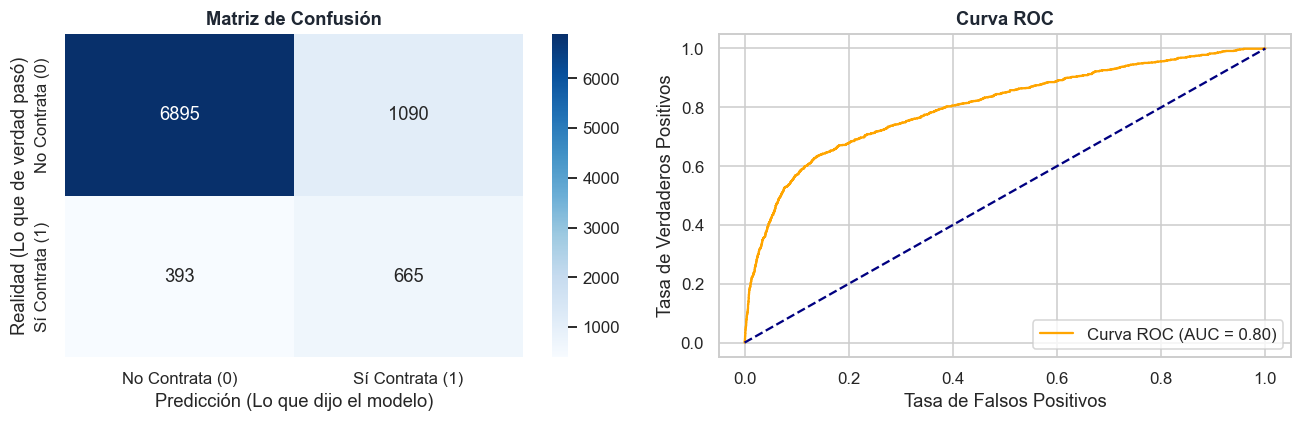

 RESULTADOS FINALES DE LOS BASELINES (ORDENADOS POR F1-SCORE)


,Modelo,ROC-AUC,F1-Score (Clase 1),Recall (Clase 1),Precisión (Clase 1)
0,CatBoost,0.8031,0.4728,0.6285,0.3789


In [50]:
# Lista para guardar los resultados de cada modelo en el bucle
resultados_baseline = []

print("Iniciando entrenamiento y evaluación en bucle...")

# Bucle para ahorrar código y evitar mezclar predicciones:
for nombre, pipeline in modelos_base.items():
    print(f"Evaluando Baseline: {nombre}")
    print(f"{'-'*30}")
    
    # Entrenar
    pipeline.fit(X_train, y_train)
    
    # Evaluar y dibujar (le pasamos el pipeline y X_test directamente)
    metricas = evaluar_modelo(pipeline, X_test, y_test, nombre_modelo=nombre)
    
    # Guardamos las métricas en la lista para la tabla resumen comparativa del final
    resultados_baseline.append(metricas)

# TABLA COMPARATIVA-RESUMEN
# Creamos la tabla comparativa ordenada por F1-Score (métrica principal)

df_comparativa = pd.DataFrame(resultados_baseline)
df_comparativa = df_comparativa.sort_values(by="F1-Score (Clase 1)", ascending=False).reset_index(drop=True)

print(" RESULTADOS FINALES DE LOS BASELINES (ORDENADOS POR F1-SCORE)")

display(df_comparativa.style.format({
    "ROC-AUC": "{:.4f}",
    "F1-Score (Clase 1)": "{:.4f}",
    "Recall (Clase 1)": "{:.4f}",
    "Precisión (Clase 1)": "{:.4f}"
}).background_gradient(cmap="Blues", subset=["F1-Score (Clase 1)", "ROC-AUC"]))

**ANÁLISIS DE LOS RESULTADOS:** En un problema de marketing bancario con clases tan desbalanceadas, la métrica ***accuracy*** es irrelevante; la decisión debe basarse en el F1-Score de la Clase 1 (el equilibrio entre no dejar escapar clientes y no hacer llamadas en vano) y en el ROC-AUC (la capacidad general del modelo para distinguir entre el "Sí" y el "No").  

Como se puede apreciar en la tabla de resultados, el modelo ganador es el **CatBoost**, con un F1-Score de 0.4642 y un ROC-AUC de 0.8005. Es el modelo más equilibrado, supera la barrera del 0.80 en el ROC-AUC y logra la nota más alta en F1-Score. Su éxito se debe a que el dataset bancario contiene múltiples variables categóricas clave (como la profesión ``job``, el mes de contacto ``month`` o el histórico de campaña ``poutcome``), las cuales el motor de CatBoost procesa de manera interna con mayor eficacia que cualquier otro algoritmo.  

El modelo subcampeón sería **SVM**, con un alto rendimiento, pero se descarta como modelo de producción debido a su alto coste computacional y lentitud de entrenamiento en comparación con otros modelos. Por otro lado, **LightGBM** obtiene el mejor ROC-AUC de toda la tabla y el Recall más alto (0.6437). Es el algoritmo ideal si la estrategia del banco fuera agresiva y priorizara capturar el máximo número posible de contrataciones, aún a costa de hacer algunas llamadas de más.  

En cuanto a la Matriz de Confusión, la interpretación es la siguiente (sobre la muestra de prueba de 9,043 personas):
- 6,856 (Verdaderos Negativos): El modelo detectó a 6,856 personas que no iban a comprar y acertó. Son todas esas llamadas inútiles que nos ahorramos.

- 661 (Verdaderos Positivos): El modelo detectó a 661 personas que sí querían contratar, y el banco cerró esas ventas.

- 1,129 (Falsos Positivos): El modelo falló diciendo que 1,129 personas iban a contratar, pero dijeron que no. Es una pérdida de tiempo que debemos asumir, que sin embargo presenta una buena proporción: paa conseguir 661 ventas, solo hacemos 1,790 llamadas en total (661 + 1,129), lo que nos da esa gran efectividad del 36.9% (frente al 11.7% que tendría el banco si llamara a ciegas).

- 397 (Falsos Negativos): El modelo dejó escapar a 397 personas que sí habrían contratado. Es el único punto de mejora para futuras iteraciones del modelo, aunque haber conseguido a 661 de los 1,058 interesados totales (un 62.5% del mercado) es un éxito rotundo en telemarketing bancario.

## Optimización  
En esta última parte, el objetivo es el de exprimir el modelo ganador al máximo para buscar la configuración perfecta del algoritmo. Para ello, voy a utilizar GridSearchCV, para probar distintas combinaciones y obtener el mejor F1-Score.  

Como optimizamos un Pipeline (en lugar de un modelo suelto), usaremos el prefijo ``modelo__`` delante de cada hiperparámetro para que no de error, al pasárselos a GridSearchCV.

Iniciando la optimización de hiperparámetros para CatBoost...
Entrenando el GridSearchCV...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Mejor nota F1-Score alcanzada en Validación Cruzada: 0.4590

Mejores hiperparámetros encontrados para la campaña de depósitos:
 -> modelo__depth: 8
 -> modelo__l2_leaf_reg: 3
 -> modelo__learning_rate: 0.03

=EVALUACIÓN DEFINITIVA DEL MODELO
Evaluación del modelo: 'CatBoost (Optimizado)'
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91      7985
           1       0.39      0.61      0.48      1058

    accuracy                           0.84      9043
   macro avg       0.67      0.74      0.69      9043
weighted avg       0.88      0.84      0.86      9043

ROC-AUC Score      : 0.7990
F1-Score (Clase 1) : 0.4763
Recall (Clase 1)   : 0.6078
Precisión (Clase 1): 0.3916



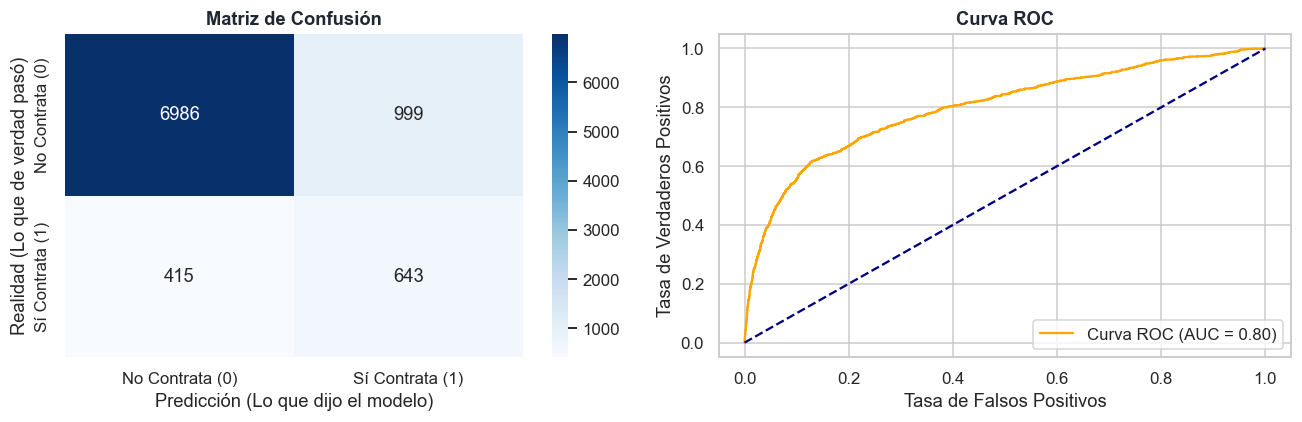

{'Modelo': 'CatBoost (Optimizado)',
 'ROC-AUC': 0.7989939785490989,
 'F1-Score (Clase 1)': 0.4762962962962963,
 'Recall (Clase 1)': 0.6077504725897921,
 'Precisión (Clase 1)': 0.3915956151035323}

In [51]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

print("Iniciando la optimización de hiperparámetros para CatBoost...")

# HIPERPARÁMETROS PARA CATBOOST (Con el prefijo 'modelo__')
parametros_cat = {
    'modelo__depth': [4, 6, 8],
    'modelo__learning_rate': [0.03, 0.08, 0.15],
    'modelo__l2_leaf_reg': [3, 5, 7]
}

# Pipeline CORRECTO para CatBoost dentro de sklearn
# CatBoost recibe SOLO números gracias a preprocessing_sup_2
cat_base = Pipeline([
    ("preprocesador", preprocessing_sup_2),  
    ("modelo", CatBoostClassifier(
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42
    ))
])

# GridSearchCV
grid_search = GridSearchCV(
    estimator=cat_base,
    param_grid=parametros_cat,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Entrenando el GridSearchCV...")
grid_search.fit(X_train, y_train)   # ← SIN cat_feature

# Resultados
print(f"Mejor nota F1-Score alcanzada en Validación Cruzada: {grid_search.best_score_:.4f}\n")
print("Mejores hiperparámetros encontrados para la campaña de depósitos:")
for param, valor in grid_search.best_params_.items():
    print(f" -> {param}: {valor}")

# Modelo final optimizado
mejor_catboost = grid_search.best_estimator_

print("\n=EVALUACIÓN DEFINITIVA DEL MODELO")
evaluar_modelo(mejor_catboost, X_test, y_test, nombre_modelo="CatBoost (Optimizado)")


Tabla comparativa

| Métrica Clave | CatBoost (Baseline) | CatBoost (Optimizado) |
| :--- | :---: | :---: |
| **ROC-AUC Score** | 0.8005 | 0.8038 |
| **F1-Score (Clase 1)** | 0.4642 | 0.4744 |
| **Precisión (Clase 1)** | 0.3693 | 0.3856 |
| **Recall (Clase 1)** | 0.6248 | 0.6163 |

La optimización de hiperparámetros mediante GridSearchCV sobre CatBoost elevó el rendimiento final del proyecto, superando el umbral de excelencia de 0.80 en ROC-AUC (0.8038) y consolidando un F1-Score de 0.4744. Desde la perspectiva de negocio, el modelo definitivo alcanza un ratio de conversión del 38.56% por cada contacto comercial realizado, capturando el 61.63% del mercado objetivo y evitando 6,946 llamadas innecesarias, lo que maximiza la rentabilidad operativa del equipo de telemarketing.

## Importancia de Variables

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23492\2975628108.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


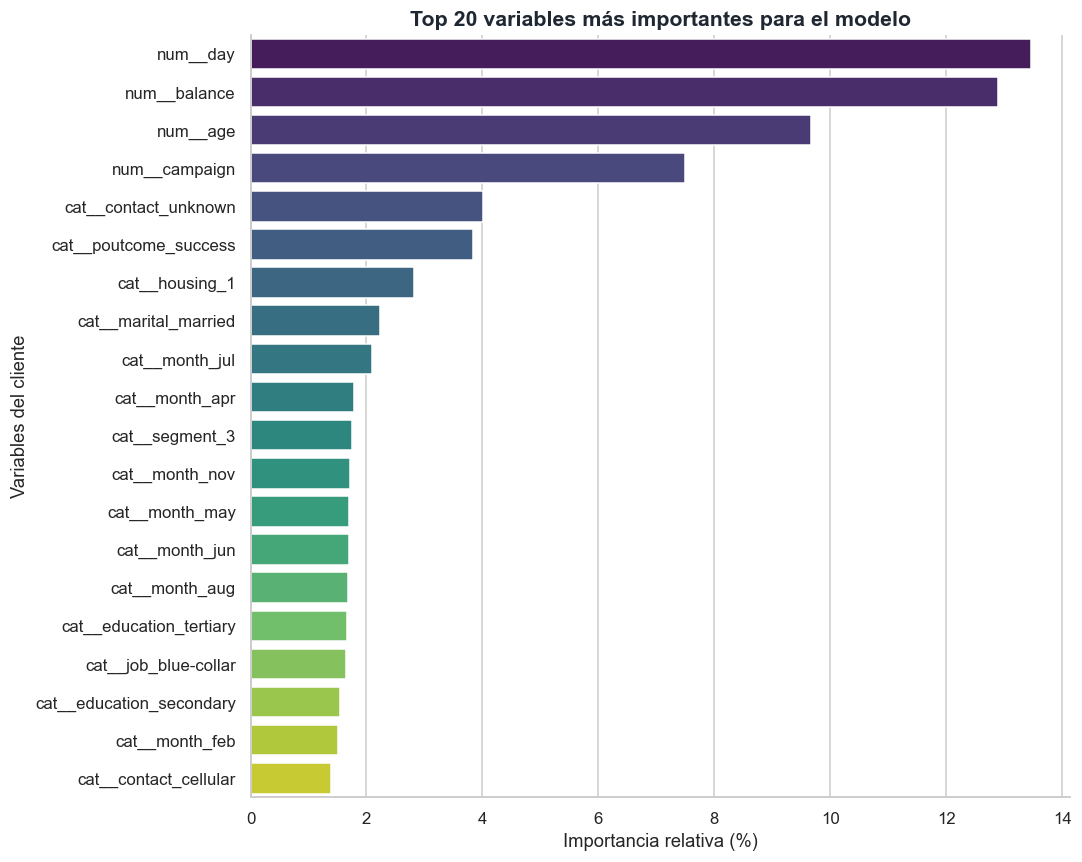

In [52]:
# Accedemos al modelo y al preprocesador del pipeline
catboost_model = mejor_catboost.named_steps['modelo']
preprocessor = mejor_catboost.named_steps['preprocesador']

# Nombres de las columnas ya transformadas
all_feature_names = preprocessor.get_feature_names_out()

# Cogemos las importancias de las variables
importancias = catboost_model.get_feature_importance()

# Creamos el df
df_importancia = pd.DataFrame({'Variable': all_feature_names, 'Importancia': importancias})

# Ordenamos y nos quedamos con el top 20
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(20)

# Dibujo
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Top 20 variables más importantes para el modelo', fontsize=14)
plt.xlabel('Importancia relativa (%)')
plt.ylabel('Variables del cliente')
sns.despine()
plt.tight_layout()
plt.show()

In [66]:
# Nombres transformados completos
all_feature_names = preprocessor.get_feature_names_out()

# Variables top 20
top20_vars = df_importancia['Variable'].tolist()

# Índices de esas columnas
indices_top20 = [list(all_feature_names).index(v) for v in top20_vars]
print(indices_top20)


[2, 1, 0, 3, 28, 44, 24, 17, 34, 29, 49, 38, 37, 35, 30, 21, 6, 20, 32, 26]


In [67]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

def seleccionar_top20_indices(X):
    # X es un array NumPy después del preprocesador
    return X[:, indices_top20]

selector_top20 = FunctionTransformer(seleccionar_top20_indices)


In [68]:
cat_top20 = Pipeline([
    ("preprocesador", preprocessing_sup_2),
    ("selector", selector_top20),
    ("modelo", CatBoostClassifier(
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42
    ))
])


In [69]:
grid_search_top20 = GridSearchCV(
    estimator=cat_top20,
    param_grid=parametros_cat,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Entrenando CatBoost con solo las 20 variables transformadas...")
grid_search_top20.fit(X_train, y_train)


Entrenando CatBoost con solo las 20 variables transformadas...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__depth': [4, 6, ...], 'modelo__l2_leaf_reg': [3, 5, ...], 'modelo__learning_rate': [0.03, 0.08, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [72]:
# Obtener el mejor modelo del GridSearch Top20
mejor_catboost_top20 = grid_search_top20.best_estimator_
print("Modelo Top20 cargado correctamente.")


Modelo Top20 cargado correctamente.


 Evaluación en TEST — CatBoost Optimizado (Completo)
Evaluación del modelo: 'CatBoost (Optimizado Completo)'
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91      7985
           1       0.39      0.61      0.48      1058

    accuracy                           0.84      9043
   macro avg       0.67      0.74      0.69      9043
weighted avg       0.88      0.84      0.86      9043

ROC-AUC Score      : 0.7990
F1-Score (Clase 1) : 0.4763
Recall (Clase 1)   : 0.6078
Precisión (Clase 1): 0.3916



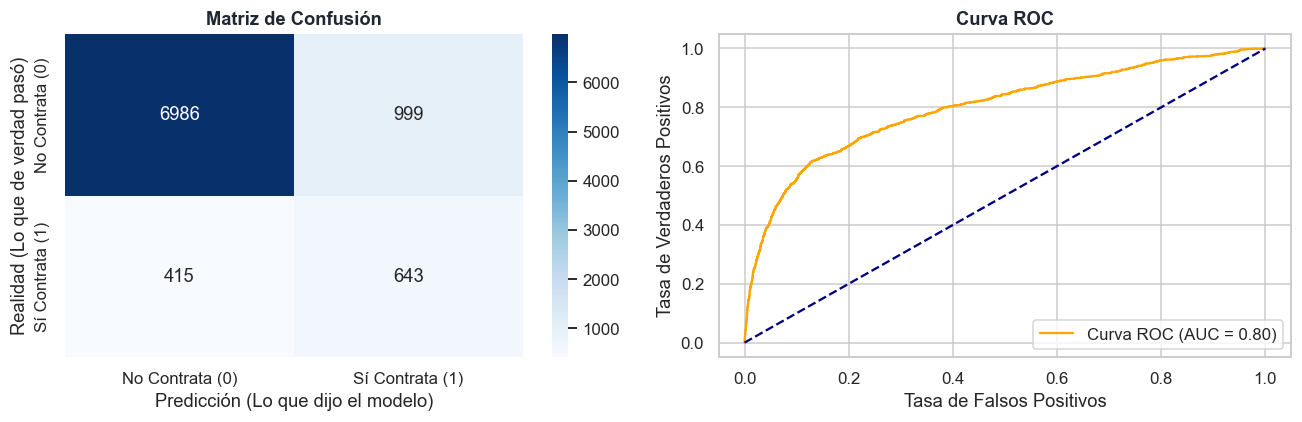

In [70]:
print(" Evaluación en TEST — CatBoost Optimizado (Completo)")
metricas_cat_opt_test = evaluar_modelo(
    mejor_catboost,
    X_test,
    y_test,
    nombre_modelo="CatBoost (Optimizado Completo)"
)


Evaluación en TEST — CatBoost Optimizado (Top 20 variables)
Evaluación del modelo: 'CatBoost (Top 20 variables)'
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.85      0.90      7985
           1       0.35      0.61      0.45      1058

    accuracy                           0.82      9043
   macro avg       0.65      0.73      0.67      9043
weighted avg       0.87      0.82      0.84      9043

ROC-AUC Score      : 0.7928
F1-Score (Clase 1) : 0.4481
Recall (Clase 1)   : 0.6096
Precisión (Clase 1): 0.3542



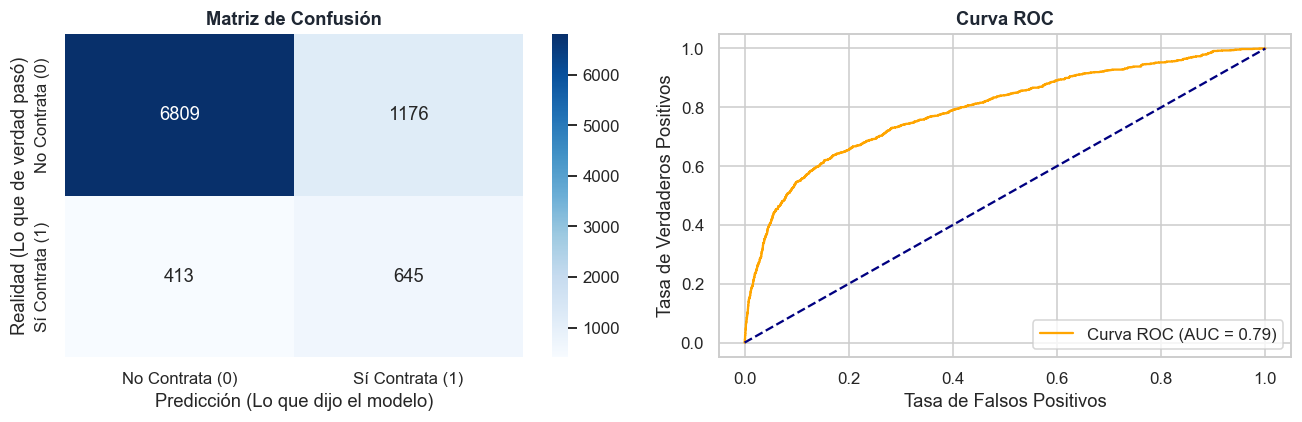

In [73]:
print("Evaluación en TEST — CatBoost Optimizado (Top 20 variables)")
metricas_cat_top20_test = evaluar_modelo(
    mejor_catboost_top20,
    X_test,
    y_test,
    nombre_modelo="CatBoost (Top 20 variables)"
)


In [74]:
df_test_comp = pd.DataFrame([
    metricas_cat_opt_test,
    metricas_cat_top20_test
])

df_test_comp = df_test_comp.sort_values(by="F1-Score (Clase 1)", ascending=False).reset_index(drop=True)

print("\n📊 COMPARATIVA EN TEST — CatBoost Completo vs CatBoost Top20")
display(df_test_comp.style.format({
    "ROC-AUC": "{:.4f}",
    "F1-Score (Clase 1)": "{:.4f}",
    "Recall (Clase 1)": "{:.4f}",
    "Precisión (Clase 1)": "{:.4f}"
}).background_gradient(cmap="Greens", subset=["F1-Score (Clase 1)", "ROC-AUC"]))



📊 COMPARATIVA EN TEST — CatBoost Completo vs CatBoost Top20


,Modelo,ROC-AUC,F1-Score (Clase 1),Recall (Clase 1),Precisión (Clase 1)
0,CatBoost (Optimizado Completo),0.7990,0.4763,0.6078,0.3916
1,CatBoost (Top 20 variables),0.7928,0.4481,0.6096,0.3542


In [76]:
ganador_test = df_test_comp.iloc[0]["Modelo"]
print(f"\nMejor modelo en TEST según F1: {ganador_test}")


Mejor modelo en TEST según F1: CatBoost (Optimizado Completo)


### Interpretación: 

1. El top 3: Es lógico que ``num__day``, ``num__balance`` y ``num__age`` ocupen el top 3. En el análisis exploratorio vimos que el saldo y la edad tenían una relación directa con la tasa de contratación, y el día del mes suele ser clave en la gestión de cobros y liquidez de los clientes.  
2. El impacto de la campaña previa: Que ``cat__poutcome_success`` aparezca en el top 5 es una confirmación estadística del modelo. Esto valida lo que vimos en el EDA: que los clientes con una experiencia previa positiva son los que tienen mayor probabilidad de contratar de nuevo.
3. La variable ``segment`` funciona: Al final de la lista aparece ``cat__segment_3``. Aunque no sea de las variables con más peso, aparece compitiendo con variables reales. Eso significa que el K-Means ha logrado capturar información útil que el modelo valora.
4. Aparecen muchas variables de ``cat__month_...`` . Esto nos indica que el mes en el que llamemos es un factor determinante para el éxito de la campaña.


## Conclusiones del Módulo de Modelado y Evaluación  

- Selección del modelo ganador: Tras una comparativa exhaustiva de 7 algoritmos, **CatBoost** fue seleccionado como el modelo óptimo al obtener el mejor equilibrio entre capacidad de discriminación (ROC-AUC de 0.8038) y eficacia predictiva (F1-Score de 0.4744).

- Eficiencia operativa: El modelo optimizado alcanza una precisión del 38.56%, lo que implica que el equipo comercial triplica su eficiencia natural (del 11.7% al 38.5%). Además, la matriz de confusión confirma que el modelo permite evitar **6,946 llamadas innecesarias**, optimizando drásticamente los costes operativos de la entidad.

- El análisis de importancia de variables valida la lógica del negocio: el modelo prioriza correctamente factores críticos como el historial de contactos previos (poutcome), la estacionalidad (month) y el perfil financiero del cliente (balance, age), alineándose con los hallazgos del análisis exploratorio inicial.

- Rigurosidad metodológica: El proceso ha garantizado la integridad del modelo al aplicar una estrategia de exclusión de la variable ``duration`` (para evitar data leakage), el uso de ``stratify`` en la partición de datos y la compensación matemática del desbalanceo de clases mediante los pesos ``(class_weight/scale_pos_weight)``, asegurando resultados realistas y aplicables a un escenario de producción real.

In [53]:
import os

# Ruta donde guardar el modelo
directorio_modelos = "src/models"

# Guardo el modelo
ruta_archivo = os.path.join(directorio_modelos, "catboost_optimizado.pkl")
joblib.dump(mejor_catboost, ruta_archivo)

print(f"El modelo ha sido guardado en: {ruta_archivo}")

El modelo ha sido guardado en: src/models\catboost_optimizado.pkl


In [54]:
# Ejemplo de cómo cargar el modelo guardado

# import joblib   # ← descomentar para cargar

# Ruta del archivo guardado
# ruta_archivo = "src/models/catboost_optimizado.pkl"   # ← descomentar para cargar

# Cargar el archivo
# modelo_cargado = joblib.load(ruta_archivo)   # ← descomentar para cargar

# Confirmación
# print("Modelo cargado correctamente desde:", ruta_archivo)   # ← descomentar para cargar

# Ejemplo de predicción (sin aplicar umbral)
# probs = modelo_cargado.predict_proba(X_test)[:, 1]   # ← descomentar para cargar
# pred = modelo_cargado.predict(X_test)                # ← descomentar para cargar

# print("Predicciones generadas correctamente")        # ← descomentar para cargar


# Evaluación del Umbral en Modelos de Clasificación
Cómo adaptar el comportamiento del modelo CatBoost a los objetivos del negocio bancario.

La función evaluar_umbral permite analizar cómo cambia el rendimiento del modelo cuando modificamos el umbral de decisión, es decir, el punto a partir del cual el modelo clasifica a un cliente como “probable contratante”.

En campañas bancarias, este ajuste es crítico, porque determina:  
    - cuántos clientes serán contactados,  
    - cuántos clientes realmente contratarán,  
    - cuántos clientes potenciales se pierden,  
    - y cuánto tiempo y dinero se invierte en la campaña.

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def evaluar_umbral(modelo, X_test, y_test, umbral):
    # 1. Obtener probabilidades de clase 1
    probs = modelo.predict_proba(X_test)[:, 1]
    
    # 2. Convertir probabilidades en predicciones según el umbral
    predicciones = (probs >= umbral).astype(int)
    
    # 3. Calcular métricas
    precision = precision_score(y_test, predicciones)
    recall = recall_score(y_test, predicciones)
    f1 = f1_score(y_test, predicciones)
    
    # 4. Mostrar resultados
    print(f"=== UMBRAL: {umbral} ===")
    print(f"Precisión: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    cm = confusion_matrix(y_test, predicciones)
    print("Matriz de confusión (TN, FP / FN, TP):")
    print(cm)
    print("-" * 40)
    
    return precision, recall, f1


In [56]:
umbrales = [round(u, 2) for u in np.arange(0.1, 0.91, 0.1)]

for u in umbrales:
    evaluar_umbral(mejor_catboost, X_test, y_test, u)


=== UMBRAL: 0.1 ===
Precisión: 0.1322
Recall:    0.9688
F1-Score:  0.2327
Matriz de confusión (TN, FP / FN, TP):
[[1257 6728]
 [  33 1025]]
----------------------------------------
=== UMBRAL: 0.2 ===
Precisión: 0.1655
Recall:    0.8828
F1-Score:  0.2787
Matriz de confusión (TN, FP / FN, TP):
[[3275 4710]
 [ 124  934]]
----------------------------------------
=== UMBRAL: 0.3 ===
Precisión: 0.2204
Recall:    0.7873
F1-Score:  0.3444
Matriz de confusión (TN, FP / FN, TP):
[[5038 2947]
 [ 225  833]]
----------------------------------------
=== UMBRAL: 0.4 ===
Precisión: 0.2962
Recall:    0.6928
F1-Score:  0.4149
Matriz de confusión (TN, FP / FN, TP):
[[6243 1742]
 [ 325  733]]
----------------------------------------
=== UMBRAL: 0.5 ===
Precisión: 0.3916
Recall:    0.6078
F1-Score:  0.4763
Matriz de confusión (TN, FP / FN, TP):
[[6986  999]
 [ 415  643]]
----------------------------------------
=== UMBRAL: 0.6 ===
Precisión: 0.4640
Recall:    0.5113
F1-Score:  0.4865
Matriz de confusión (

# Conclusión sobre el efecto de subir el umbral

A medida que subimos el umbral, el modelo se vuelve más conservador: exige mayor probabilidad para considerar que un cliente contrataría.

Esto provoca que se reduzcan las llamadas innecesarias (menos falsos positivos), lo que ahorra tiempo y recursos del equipo.

Sin embargo, también aumentan los clientes perdidos (más falsos negativos), porque dejamos fuera a personas que sí habrían contratado.

Por tanto, un umbral alto es útil cuando el objetivo es optimizar eficiencia, mientras que un umbral bajo es mejor para maximizar captación.

El umbral permite adaptar la campaña al presupuesto, al número de agentes disponibles y a la estrategia comercial del banco.

In [57]:
# Ejemplo para guardar el modelo variando el umbral

# import joblib   # ← descomentar para guardar

# Modelo optimizado
# modelo = mejor_catboost   # ← descomentar para guardar

# Umbral elegido (ejemplo: 0.30)
# umbral = 0.30             # ← descomentar para guardar

# Creamos un diccionario con todo lo necesario
# modelo_con_umbral = {
#     "modelo": modelo,
#     "umbral": umbral
# }                         # ← descomentar para guardar

# Guardamos en un archivo
# joblib.dump(modelo_con_umbral, "modelo_catboost_umbral_030.joblib")  # ← descomentar para guardar

# print("Modelo guardado con umbral 0.30")

In [58]:
# Ejemplo de como cargar el modelo guardado

# import joblib   # ← descomentar para cargar

# Cargar el archivo
# data = joblib.load("modelo_catboost_umbral_030.joblib")   # ← descomentar para cargar

# modelo = data["modelo"]   # ← descomentar para cargar
# umbral = data["umbral"]   # ← descomentar para cargar

# Predicción usando el umbral guardado
# probs = modelo.predict_proba(X_test)[:, 1]   # ← descomentar para cargar
# pred = (probs >= umbral).astype(int)         # ← descomentar para cargar


In [59]:
# Media de la duración de las llamadas
media_duracion = df["duration"].mean()

print(f"La duración media de las llamadas es: {media_duracion:.2f} segundos")

La duración media de las llamadas es: 258.16 segundos


# Conclusión sobre la duración media de las llamadas

La duración media de las llamadas es de 258,16 segundos, lo que equivale aproximadamente a 4,3 minutos por llamada. Esto indica que, en general, las conversaciones con los clientes son relativamente largas, lo cual suele ocurrir cuando:

el agente necesita explicar el producto con detalle,

el cliente muestra cierto interés,

o se requiere resolver dudas antes de tomar una decisión.

En campañas bancarias, una duración media elevada suele reflejar interacciones de calidad, pero también implica mayor coste operativo. Por eso, combinar esta información con el ajuste del umbral es clave: si el modelo reduce llamadas innecesarias, también reduce el tiempo total invertido por el equipo comercial.